In [1]:
import sys
import os

In [2]:
# from helpers.dataframeBuilder import get_df_neigbours_answer_for_all_itemIDs
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../csv/preprocessed_data.csv')

In [4]:
X = df.select_dtypes(include=[np.number]).values

In [5]:
# Vervang NaN-waarden door de mediaan van elke kolom
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

In [6]:
X = X.astype(np.float64)

In [7]:
print(X.shape)

(6894, 46)


# Modellen trainen

In [8]:
# voor elke model dezelfde contamination
contamination= 0.01

In [9]:
def predict_model(model, name):
    df_answers=df
    
    model.fit(X)
    
    df_answers['anomaly_score'] = model.decision_scores_
    df_answers['is_anomaly'] = model.predict(X)

    df_answers = df_answers.reset_index()
    df_answers = df_answers[['TestKey','anomaly_score', 'is_anomaly']]
    
    print(f"Aantal gedetecteerde anomalieën: {df_answers['is_anomaly'].sum()}")

    df_answers.set_index('TestKey', inplace=True)
    df_answers.to_csv(f"../csv/{name}.csv")
    df_answers.reset_index(inplace=True)
    
    return df_answers

## ECOD

In [10]:
from pyod.models.ecod import ECOD

ecod = ECOD(contamination=contamination)

In [11]:
df_ecod = predict_model(ecod, "ecod")

Aantal gedetecteerde anomalieën: 69


In [12]:
df_ecod[df_ecod['is_anomaly'] == 1].head()

,TestKey,anomaly_score,is_anomaly
14,160082,59.500762,1
33,160101,58.584483,1
245,160313,58.828529,1
266,160334,82.756864,1
418,160486,107.436468,1


## Isolation forest

In [13]:
from pyod.models.iforest import IForest

i_forest = IForest(contamination=contamination, n_estimators=100, max_samples='auto')

In [14]:
df_iForest = predict_model(i_forest, 'i_forest')

Aantal gedetecteerde anomalieën: 69


## LOF

In [15]:
from pyod.models.lof import LOF

lof = LOF(contamination=contamination)

In [16]:
df_lof = predict_model(lof, 'lof')

Aantal gedetecteerde anomalieën: 58


## COPOD 

In [ ]:
from pyod.models.copod import COPOD

copod = COPOD(contamination=contamination)

In [18]:
df_copod = predict_model(copod, 'copod')

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:    9.6s remaining:  1.1min
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:   10.8s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:    0.0s finished


Aantal gedetecteerde anomalieën: 69


## ABOD

In [19]:
from pyod.models.abod import ABOD

abod = ABOD(contamination=contamination, method='fast', n_neighbors=10)

In [20]:
df_abod = predict_model(abod, 'abod')

Aantal gedetecteerde anomalieën: 90


In [21]:
df_abod[df_abod['is_anomaly'] == 1].head()

,TestKey,anomaly_score,is_anomaly
33,160101,-4.726061e-07,1
105,160173,-4.795820e-07,1
186,160254,-3.587707e-07,1
245,160313,-3.301597e-07,1
294,160362,-4.566507e-07,1


## Overeenkomsten

### functie voor analyse

In [22]:
df_copod

,TestKey,anomaly_score,is_anomaly
0,160068,42.961978,0
1,160069,46.003079,0
2,160070,41.364169,0
3,160071,36.567663,0
4,160072,46.985761,0
...,...,...,...
6889,166957,46.600832,0
6890,166958,46.793710,0
6891,166959,46.172181,0
6892,166960,50.418076,1


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn2

def compare_anomaly_models(*model_dfs, id_column='TestKey'):
    """
    Vergelijkt anomaliedetecties van meerdere modellen.
    
    :param model_dfs: Een lijst van tuples, elk met (dataframe, model_name)
    :param id_column: De naam van de kolom die als identifier wordt gebruikt
    :return: Een DataFrame met gecombineerde resultaten
    """
    # Initialiseer de gecombineerde DataFrame met de ID-kolom
    df_combined = pd.DataFrame({id_column: model_dfs[0][0][id_column]})
    
    # Voeg resultaten van elk model toe
    model_names = []
    for df, model_name in model_dfs:
        model_names.append(model_name)
        df_combined = df_combined.merge(
            df[[id_column, 'is_anomaly']],
            on=id_column,
            suffixes=('', f'_{model_name}')
        )
        df_combined = df_combined.rename(columns={'is_anomaly': f'{model_name}_anomaly'})
    
    # Tel het aantal anomaliedetecties per datapunt
    anomaly_columns = [col for col in df_combined.columns if col.endswith('_anomaly')]
    df_combined['anomaly_count'] = df_combined[anomaly_columns].sum(axis=1)
    
    # Analyseer de overeenkomsten
    print("Verdeling van anomaliedetecties:")
    print(df_combined['anomaly_count'].value_counts().sort_index())
    
    # # Visualiseer de overeenkomsten
    plt.figure(figsize=(10, 6))
    df_combined['anomaly_count'].value_counts().sort_index().plot(kind='bar')
    plt.title('Aantal datapunten gedetecteerd als anomalie door x modellen')
    plt.xlabel('Aantal modellen')
    plt.ylabel('Aantal datapunten')
    plt.show()
    
    # Bekijk consensus anomalieën
    consensus_anomalies = df_combined[df_combined['anomaly_count'] == len(model_dfs)]
    print(f"\nAantal datapunten gedetecteerd als anomalie door alle {len(model_dfs)} modellen:", 
          len(consensus_anomalies))
    # print("\nVoorbeelden van consensus anomalieën:")
    # print(consensus_anomalies.head())
    
    # Vergelijk modellen paarsgewijs
    print("\nPaarsgewijze vergelijking van modellen:")
    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            agreement = (df_combined[f'{model_names[i]}_anomaly'] == df_combined[f'{model_names[j]}_anomaly']).mean()
            print(f"Overeenkomst tussen {model_names[i].upper()} en {model_names[j].upper()}: {agreement:.2%}")
    
    # Visualiseer de overlap van anomalieën met een Venn diagram alleen als er 3 modellen zijn
    if len(model_names) == 3:
        plt.figure(figsize=(8, 7))
        venn3([set(df_combined[df_combined[f'{model}_anomaly'] == 1][id_column]) for model in model_names],
              set_labels=model_names)
        plt.title("Overlap van gedetecteerde anomalieën")
        plt.show()
    else:
        print("\nVenn diagram wordt alleen gemaakt voor exact 3 modellen.")
    
    return df_combined

In [24]:
df_ecod

,TestKey,anomaly_score,is_anomaly
0,160068,50.484388,0
1,160069,54.429899,0
2,160070,52.242653,0
3,160071,48.872212,0
4,160072,52.129492,0
...,...,...,...
6889,166957,57.269137,0
6890,166958,53.853327,0
6891,166959,54.227706,0
6892,166960,56.653276,0


In [25]:
df_iForest

,TestKey,anomaly_score,is_anomaly
0,160068,-0.060530,0
1,160069,-0.047367,0
2,160070,-0.069272,0
3,160071,-0.089951,0
4,160072,-0.059711,0
...,...,...,...
6889,166957,-0.050719,0
6890,166958,-0.043346,0
6891,166959,-0.052090,0
6892,166960,-0.044878,0


In [26]:
df_copod

,TestKey,anomaly_score,is_anomaly
0,160068,42.961978,0
1,160069,46.003079,0
2,160070,41.364169,0
3,160071,36.567663,0
4,160072,46.985761,0
...,...,...,...
6889,166957,46.600832,0
6890,166958,46.793710,0
6891,166959,46.172181,0
6892,166960,50.418076,1


### uitvoeren

Verdeling van anomaliedetecties:
anomaly_count
0    6788
1      43
2      25
3      38
Name: count, dtype: int64


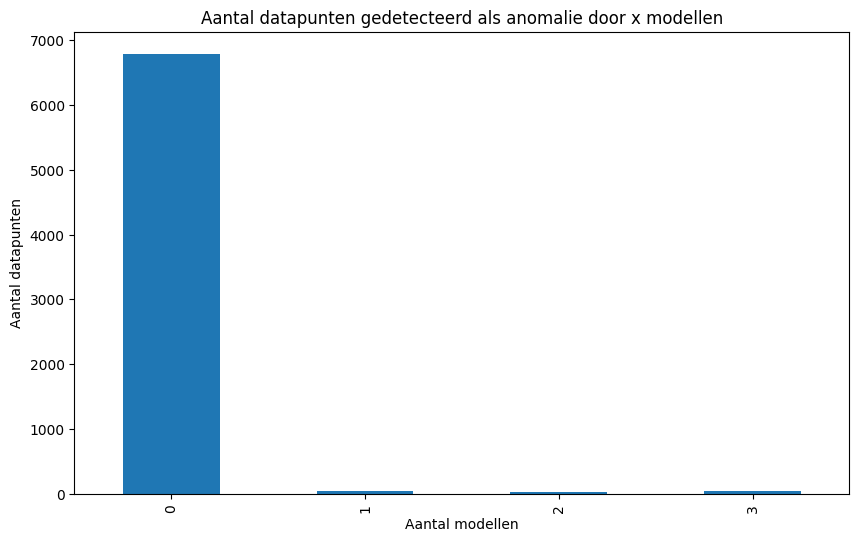


Aantal datapunten gedetecteerd als anomalie door alle 3 modellen: 38

Paarsgewijze vergelijking van modellen:
Overeenkomst tussen ECOD en I_FOREST: 99.16%
Overeenkomst tussen ECOD en COPOD: 99.77%
Overeenkomst tussen I_FOREST en COPOD: 99.10%


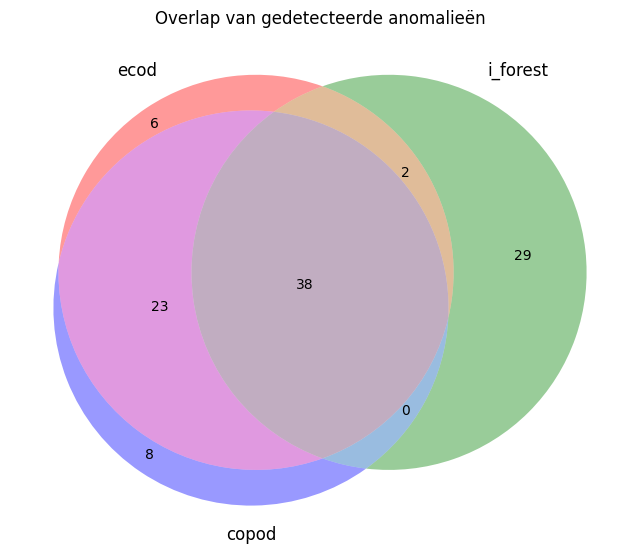

In [27]:
df_combined = compare_anomaly_models(
    (df_ecod, 'ecod'),
    (df_iForest, 'i_forest'),
    # (df_lof, 'lof'),
    (df_copod, 'copod'),
)

In [28]:
df_combined

,TestKey,ecod_anomaly,i_forest_anomaly,copod_anomaly,anomaly_count
0,160068,0,0,0,0
1,160069,0,0,0,0
2,160070,0,0,0,0
3,160071,0,0,0,0
4,160072,0,0,0,0
...,...,...,...,...,...
6889,166957,0,0,0,0
6890,166958,0,0,0,0
6891,166959,0,0,0,0
6892,166960,0,0,1,1


In [29]:
# df_combined.to_csv('../csv/comparison.csv', index=False)

# SOUD

In [ ]:
# from pyod.models.suod import SUOD
# from pyod.models.lof import LOF
# from pyod.models.iforest import IForest
# from pyod.models.copod import COPOD
# from pyod.models.knn import KNN
# from pyod.models.hbos import HBOS

In [ ]:
# base_estimators = [
#     IForest(n_estimators=100, max_samples='auto', contamination=contamination, random_state=42),
#     # LOF(n_neighbors=20, contamination=contamination),
#     ECOD(contamination=contamination),
#     COPOD(contamination=contamination)
# ]

In [ ]:
# # Initialiseer SUOD
# suod = SUOD(base_estimators=base_estimators, 
#             n_jobs=2,  # aantal parallelle jobs
#             combination='average',  # methode om scores te combineren
#             verbose=False)

In [ ]:
# def data_generator(X, batch_size=1000):
#     for i in range(0, len(X), batch_size):
#         yield X[i:i + batch_size]

In [ ]:
# # Functie om SUOD te trainen en voorspellingen te maken met batches
# def process_batches(X, batch_size=1000):
#     anomaly_scores = []
    
#     # Train SUOD op batches
#     for batch in data_generator(X, batch_size):
#         suod.fit(batch)  # Train op de huidige batch
#         batch_scores = suod.decision_function(batch)  # Verkrijg anomalie scores voor de batch
#         anomaly_scores.extend(batch_scores)  # Voeg scores toe aan de lijst
    
#     return np.array(anomaly_scores)

In [ ]:
# # Verwerk de data in batches en verkrijg anomalie scores
# anomaly_scores = process_batches(X, batch_size=1000)

# # Bepaal anomalieën op basis van de scores (bijvoorbeeld top 5% als anomalieën)
# threshold = np.percentile(anomaly_scores, 95)  # Drempelwaarde instellen
# is_anomaly = anomaly_scores > threshold

RandomForestRegressor()



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    4.3s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


RandomForestRegressor()



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


...

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


RandomForestRegressor()



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


In [ ]:
# df_suod = pd.DataFrame({
#     'TestKey': np.arange(1, len(X) + 1),  # Voeg een identificatiekolom toe (bijv. FCATestKey)
#     'anomaly_score': anomaly_scores,
#     'is_anomaly': is_anomaly.astype(int)  # Zet booleans om naar integers (0 of 1)
# })

In [ ]:
# print(f"Aantal gedetecteerde anomalieën: {df_suod['is_anomaly'].sum()}")
# print(df_suod.head())  # Toon de eerste paar resultaten

Aantal gedetecteerde anomalieën: 345
   TestKey  anomaly_score  is_anomaly
0        1       0.110172           0
1        2       0.581311           0
2        3       0.111502           0
3        4      -0.787578           0
4        5       0.582380           0


In [ ]:
# df_suod = df_suod.set_index('TestKey')
# df_suod.to_csv('../csv/suod_sjt.csv')